# Experiments -- PCA vs Autoencoder vs VAE on S&P 500 log returns

Each cell below runs one experiment, saves its CSV under `results/` and
its plot under `plots/`, and overlays the result on a shared figure where
applicable. The data is loaded ONCE at the top so every experiment sees
the same train/test split and the same train-only standardisation.

**Architecture / training knobs (edit per-cell to override the defaults
from `src.autoencoder` / `src.vae`):**
- `encoder_hidden` / `decoder_hidden` -- lists of hidden-layer sizes
- `activation` -- one of `'sigmoid'`, `'relu'`, `'tanh'`
- `beta` -- VAE KL weight (VAE only; <1 ~ plain AE, >1 ~ beta-VAE)
- `component_grid` -- the list of bottleneck sizes k to sweep

## Setup

In [ ]:
import os

from src import data as data_mod
from src import pca as pca_mod
from src import autoencoder as ae_mod
from src import vae as vae_mod
from src import vae_tstudent as vaet_mod
from src import prediction as pred_mod
from src import plotting as plotting_mod
from src.plotting import PLOTS_DIR

plotting_mod.setup_style()

RESULTS_DIR = 'results/'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR,   exist_ok=True)

# Shared dataset for every experiment in this notebook.
data = data_mod.prepare_data()
print(f'X_train: {data["X_train"].shape}, X_test: {data["X_test"].shape}, d={data["d"]}')
print(f'torch device: {ae_mod.DEVICE}')

## 1. PCA on its own
Sweeps `n_components` over the shared component grid.

[PCA] k=  1  train R^2=0.3254  test R^2=0.1472  train MSE=0.6746  test MSE=0.7329
[PCA] k=  2  train R^2=0.3819  test R^2=0.1901  train MSE=0.6181  test MSE=0.6961
[PCA] k=  4  train R^2=0.4281  test R^2=0.2306  train MSE=0.5719  test MSE=0.6613
[PCA] k=  8  train R^2=0.4767  test R^2=0.2924  train MSE=0.5233  test MSE=0.6082
[PCA] k= 16  train R^2=0.5313  test R^2=0.3323  train MSE=0.4687  test MSE=0.5738
[PCA] k= 32  train R^2=0.5977  test R^2=0.3807  train MSE=0.4023  test MSE=0.5322


,train_preserved_variance,test_preserved_variance,residual_entropy,train_mse,test_mse
k,,,,,
1,0.325400,0.147232,402.881189,0.674599,0.732879
2,0.381876,0.190067,399.822358,0.618124,0.696066
4,0.428107,0.230569,394.635452,0.571892,0.661258
8,0.476681,0.292357,385.489208,0.523319,0.608157
16,0.531321,0.332343,369.529149,0.468678,0.573792
32,0.597729,0.380733,341.534872,0.402271,0.532206


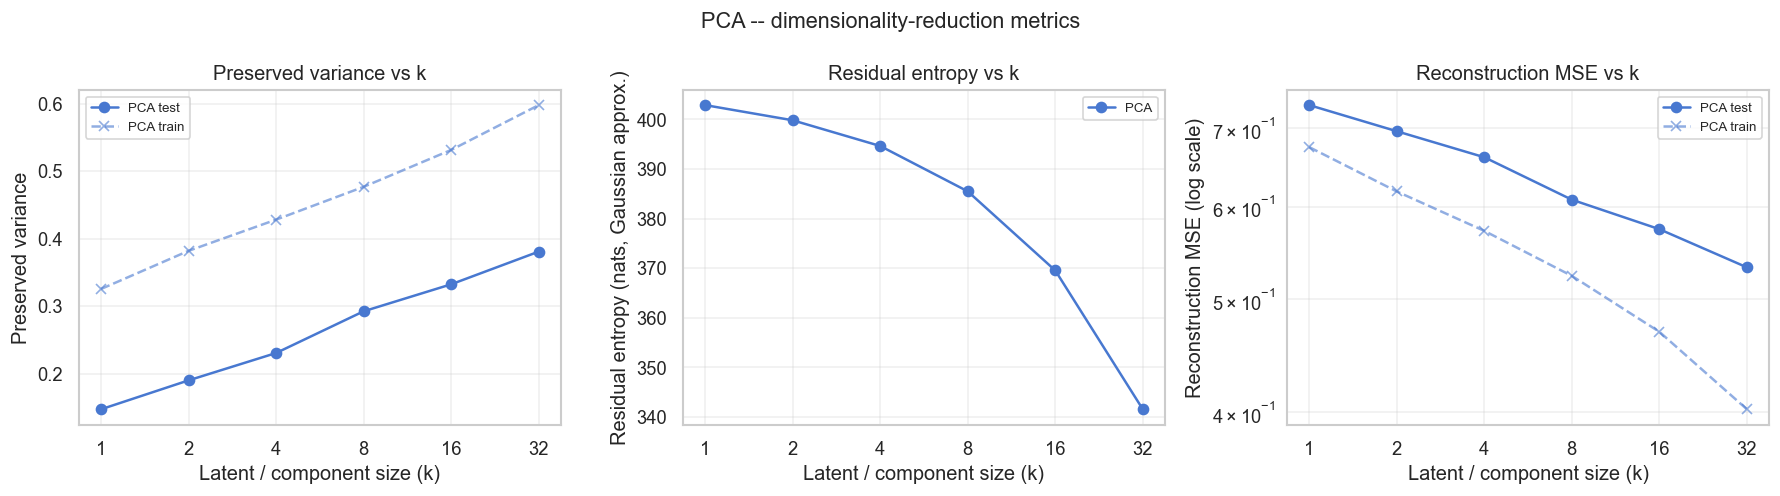

In [2]:
pca_results = pca_mod.run_pca_experiment(
    data,
    component_grid=pca_mod.COMPONENT_GRID,
)
pca_results.to_csv(RESULTS_DIR + 'pca_experiments.csv', float_format='%.6f')

plotting_mod.plot_experiments_comparison(
    {'PCA': pca_results},
    title='PCA -- dimensionality-reduction metrics',
    save_path=PLOTS_DIR + 'plot_pca_experiments.png',
)
pca_results.round(6)

## 2. Autoencoder on its own
Default architecture is `[d, 64, k, 64, d]` with sigmoid activations.
Change `encoder_hidden`, `decoder_hidden`, or `activation` here to try a different model.

[AE/relu] k=  1  training [470, 64, 1, 64, 470] ...
[AE/relu] k=  1  train R^2=0.2604  test R^2=0.0960  train MSE=0.7396  test MSE=0.7769
[AE/relu] k=  2  training [470, 64, 2, 64, 470] ...
[AE/relu] k=  2  train R^2=0.3823  test R^2=0.1803  train MSE=0.6177  test MSE=0.7045
[AE/relu] k=  4  training [470, 64, 4, 64, 470] ...
[AE/relu] k=  4  train R^2=0.4281  test R^2=0.2110  train MSE=0.5719  test MSE=0.6781
[AE/relu] k=  8  training [470, 64, 8, 64, 470] ...
[AE/relu] k=  8  train R^2=0.4771  test R^2=0.2584  train MSE=0.5229  test MSE=0.6373
[AE/relu] k= 16  training [470, 64, 16, 64, 470] ...
[AE/relu] k= 16  train R^2=0.5207  test R^2=0.2977  train MSE=0.4793  test MSE=0.6036
[AE/relu] k= 32  training [470, 64, 32, 64, 470] ...
[AE/relu] k= 32  train R^2=0.5654  test R^2=0.3182  train MSE=0.4346  test MSE=0.5860


,train_preserved_variance,test_preserved_variance,residual_entropy,train_mse,test_mse
k,,,,,
1,0.260392,0.096024,406.735830,0.739608,0.776888
2,0.382294,0.180294,400.060278,0.617706,0.704465
4,0.428104,0.211020,394.767682,0.571896,0.678058
8,0.477078,0.258426,384.661530,0.522922,0.637317
16,0.520697,0.297687,368.627509,0.479303,0.603576
32,0.565376,0.318175,348.844139,0.434624,0.585968


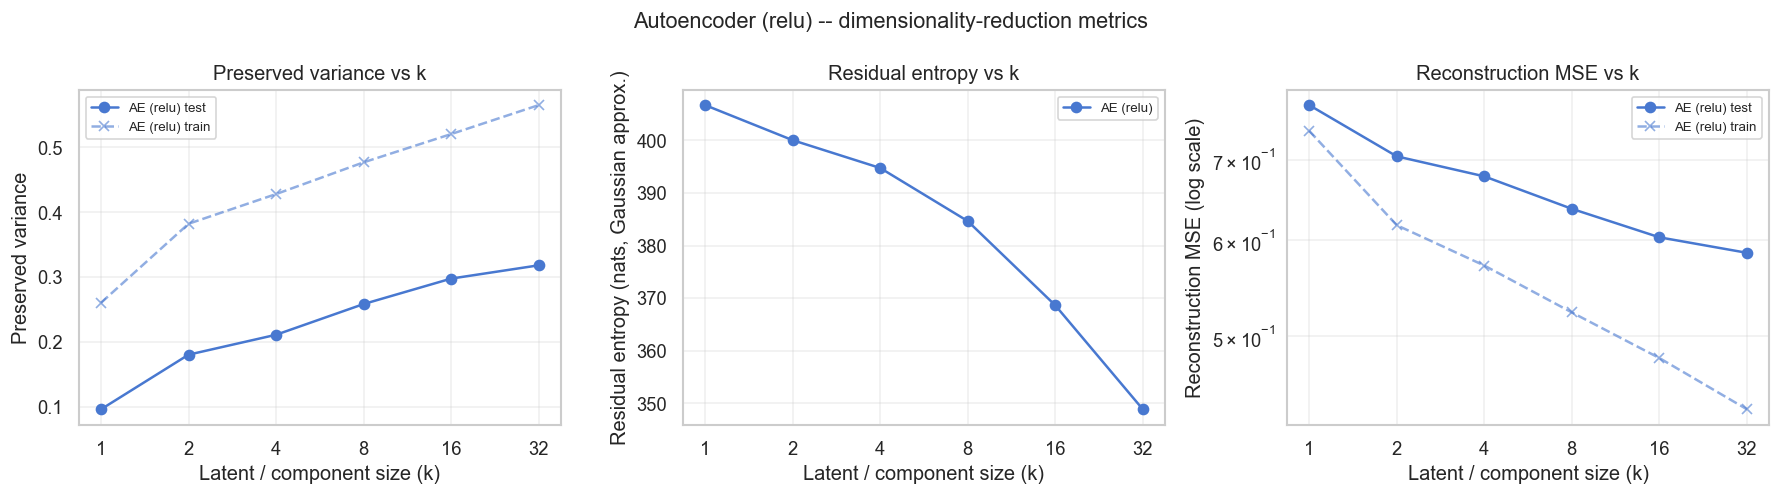

In [3]:
encoder_hidden = [64]
decoder_hidden = [64]
activation     = 'relu'

ae_results = ae_mod.run_ae_experiment(
    data,
    component_grid=ae_mod.COMPONENT_GRID,
    encoder_hidden=encoder_hidden,
    decoder_hidden=decoder_hidden,
    activation=activation,
)
ae_results.to_csv(RESULTS_DIR + f'autoencoder_experiments_{activation}.csv', float_format='%.6f')

plotting_mod.plot_experiments_comparison(
    {f'AE ({activation})': ae_results},
    title=f'Autoencoder ({activation}) -- dimensionality-reduction metrics',
    save_path=PLOTS_DIR + f'plot_autoencoder_experiments_{activation}.png',
)
ae_results.round(6)

## 3. PCA vs Autoencoder
Overlays the two methods on a single figure. Colour = method, linestyle = split.

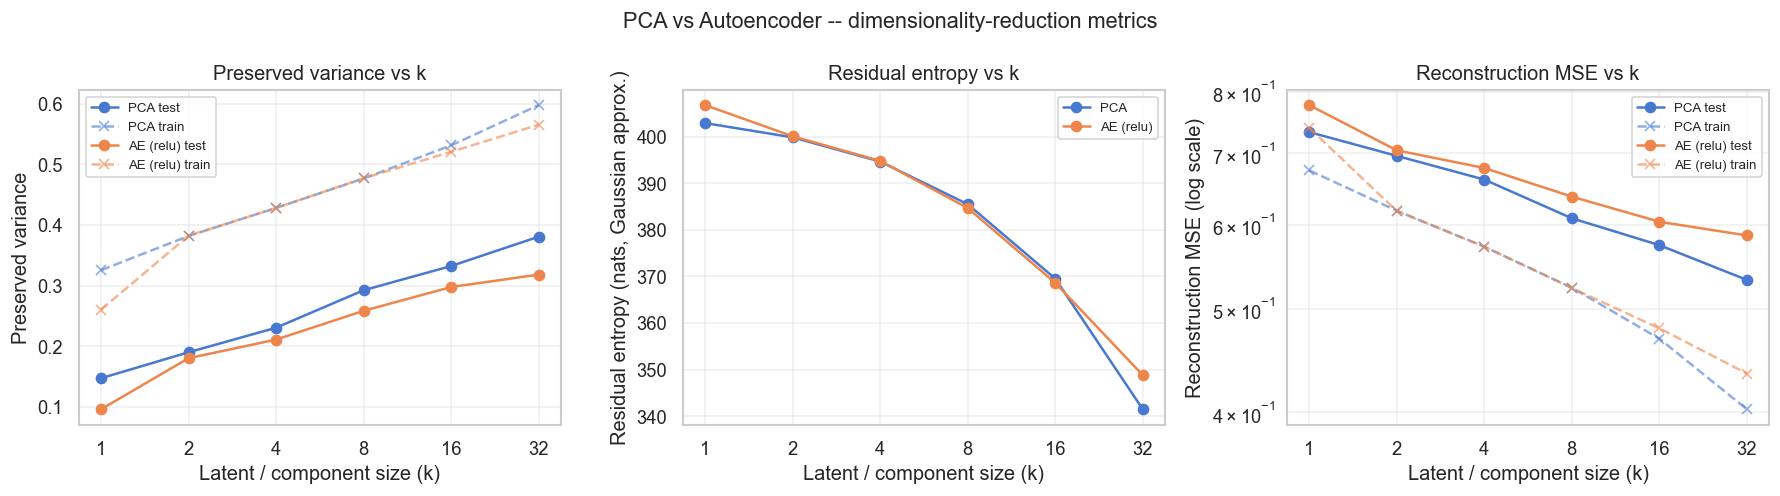

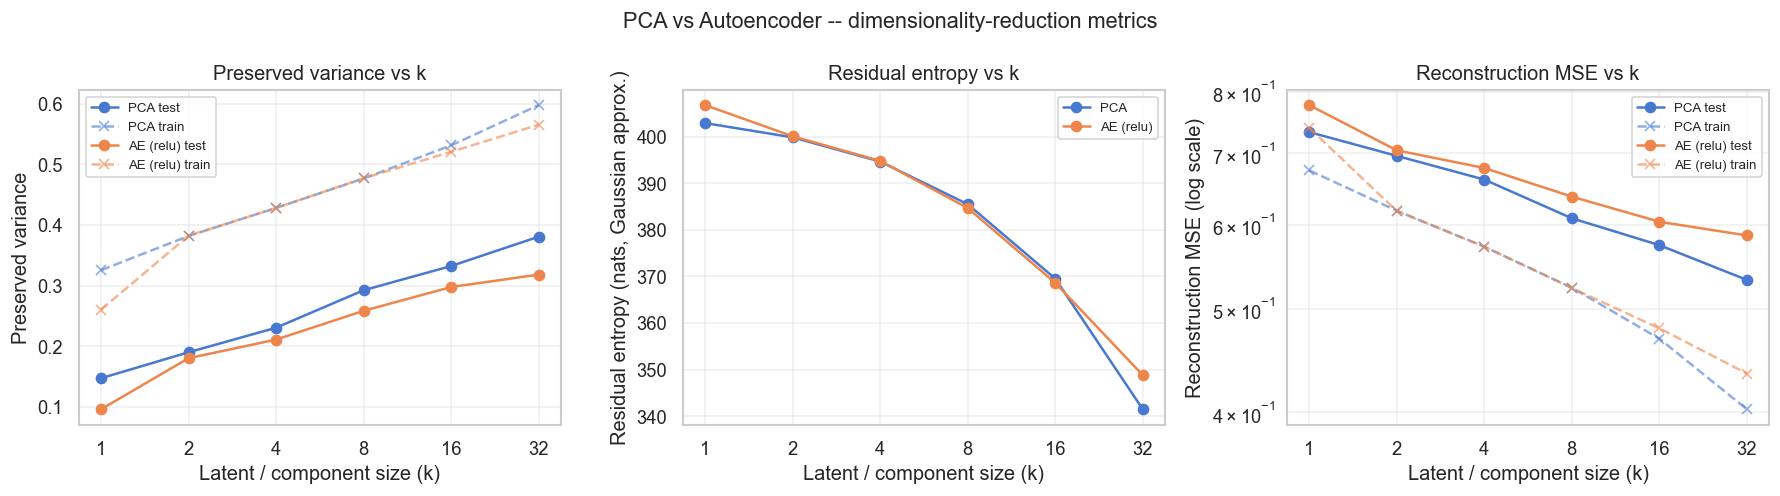

In [4]:
# Re-uses the results from sections 1 and 2 -- no retraining.
plotting_mod.plot_experiments_comparison(
    {'PCA': pca_results, f'AE ({activation})': ae_results},
    title='PCA vs Autoencoder -- dimensionality-reduction metrics',
    save_path=PLOTS_DIR + 'plot_combined_experiments.png',
)

## 4. Autoencoder activation sweep
Trains the same architecture with sigmoid / relu / tanh and overlays them.


=== activation: leakyrelu ===
[AE/leakyrelu] k=  1  training [470, 64, 1, 64, 470] ...
[AE/leakyrelu] k=  1  train R^2=0.3276  test R^2=0.1450  train MSE=0.6724  test MSE=0.7348
[AE/leakyrelu] k=  2  training [470, 64, 2, 64, 470] ...
[AE/leakyrelu] k=  2  train R^2=0.3826  test R^2=0.1799  train MSE=0.6174  test MSE=0.7048
[AE/leakyrelu] k=  4  training [470, 64, 4, 64, 470] ...
[AE/leakyrelu] k=  4  train R^2=0.4308  test R^2=0.2138  train MSE=0.5692  test MSE=0.6757
[AE/leakyrelu] k=  8  training [470, 64, 8, 64, 470] ...
[AE/leakyrelu] k=  8  train R^2=0.4730  test R^2=0.2575  train MSE=0.5270  test MSE=0.6381
[AE/leakyrelu] k= 16  training [470, 64, 16, 64, 470] ...
[AE/leakyrelu] k= 16  train R^2=0.5178  test R^2=0.2950  train MSE=0.4822  test MSE=0.6059
[AE/leakyrelu] k= 32  training [470, 64, 32, 64, 470] ...
[AE/leakyrelu] k= 32  train R^2=0.5662  test R^2=0.3189  train MSE=0.4338  test MSE=0.5854

=== activation: sigmoid ===
[AE/sigmoid] k=  1  training [470, 64, 1, 64, 470]

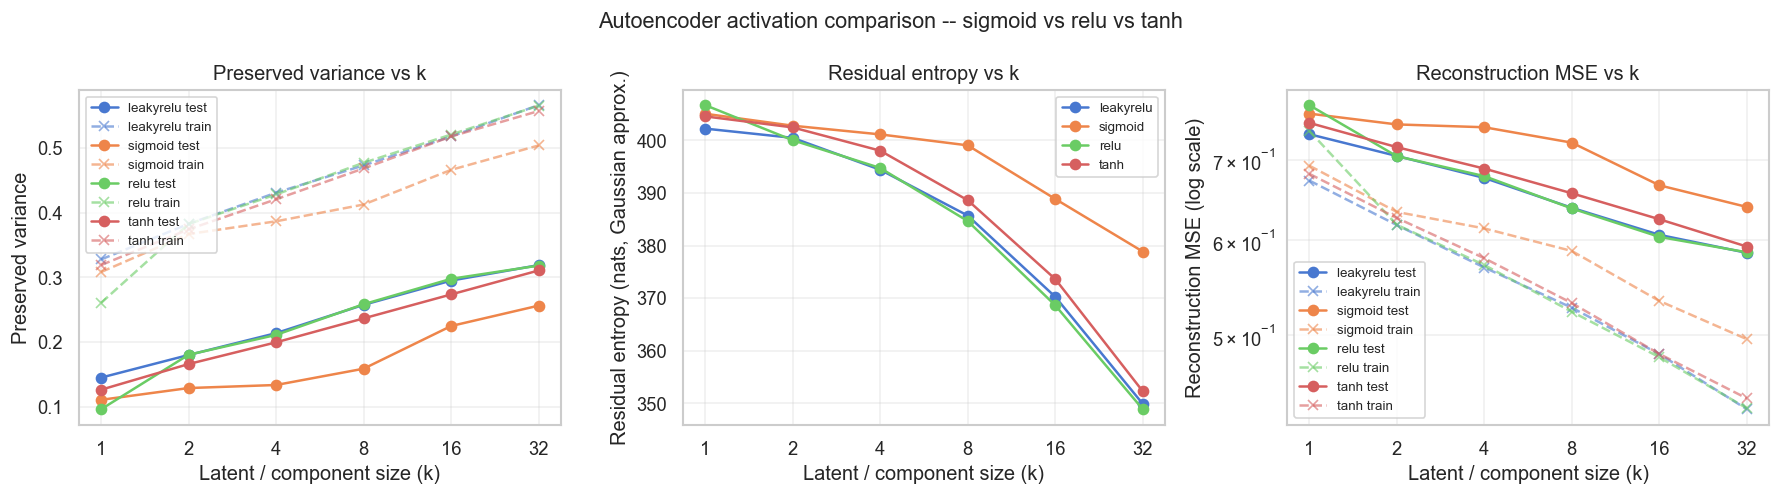

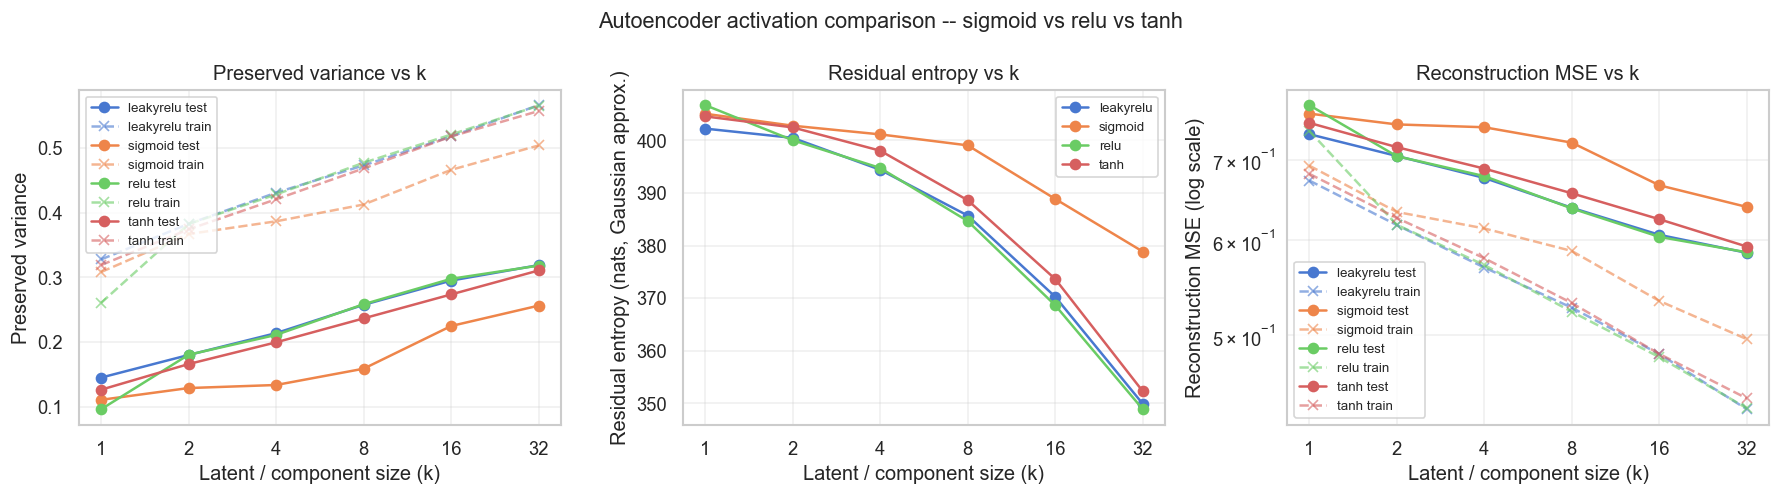

In [5]:
encoder_hidden = [64]
decoder_hidden = [64]

activation_results = {}
for act in [ 'leakyrelu', 'sigmoid', 'relu', 'tanh',]:
    print(f'\n=== activation: {act} ===')
    df = ae_mod.run_ae_experiment(
        data,
        component_grid=ae_mod.COMPONENT_GRID,
        encoder_hidden=encoder_hidden,
        decoder_hidden=decoder_hidden,
        activation=act,
    )
    df.to_csv(RESULTS_DIR + f'autoencoder_experiments_{act}.csv', float_format='%.6f')
    activation_results[act] = df

plotting_mod.plot_experiments_comparison(
    activation_results,
    title='Autoencoder activation comparison -- sigmoid vs relu vs tanh',
    save_path=PLOTS_DIR + 'plot_activation_comparison.png',
)

## 5. Autoencoder architecture sweep
Compare several encoder/decoder shapes on one figure. Add or remove entries in the
`architectures` dict below to change which ones are run.


=== architecture [64] ===
[AE/relu] k=  1  training [470, 64, 1, 64, 470] ...
[AE/relu] k=  1  train R^2=0.2604  test R^2=0.0960  train MSE=0.7396  test MSE=0.7769
[AE/relu] k=  2  training [470, 64, 2, 64, 470] ...
[AE/relu] k=  2  train R^2=0.3823  test R^2=0.1803  train MSE=0.6177  test MSE=0.7045
[AE/relu] k=  4  training [470, 64, 4, 64, 470] ...
[AE/relu] k=  4  train R^2=0.4281  test R^2=0.2110  train MSE=0.5719  test MSE=0.6781
[AE/relu] k=  8  training [470, 64, 8, 64, 470] ...
[AE/relu] k=  8  train R^2=0.4771  test R^2=0.2584  train MSE=0.5229  test MSE=0.6373
[AE/relu] k= 16  training [470, 64, 16, 64, 470] ...
[AE/relu] k= 16  train R^2=0.5207  test R^2=0.2977  train MSE=0.4793  test MSE=0.6036
[AE/relu] k= 32  training [470, 64, 32, 64, 470] ...
[AE/relu] k= 32  train R^2=0.5654  test R^2=0.3182  train MSE=0.4346  test MSE=0.5860

=== architecture [128, 64] ===
[AE/relu] k=  1  training [470, 128, 64, 1, 64, 128, 470] ...
[AE/relu] k=  1  train R^2=0.3200  test R^2=0.125

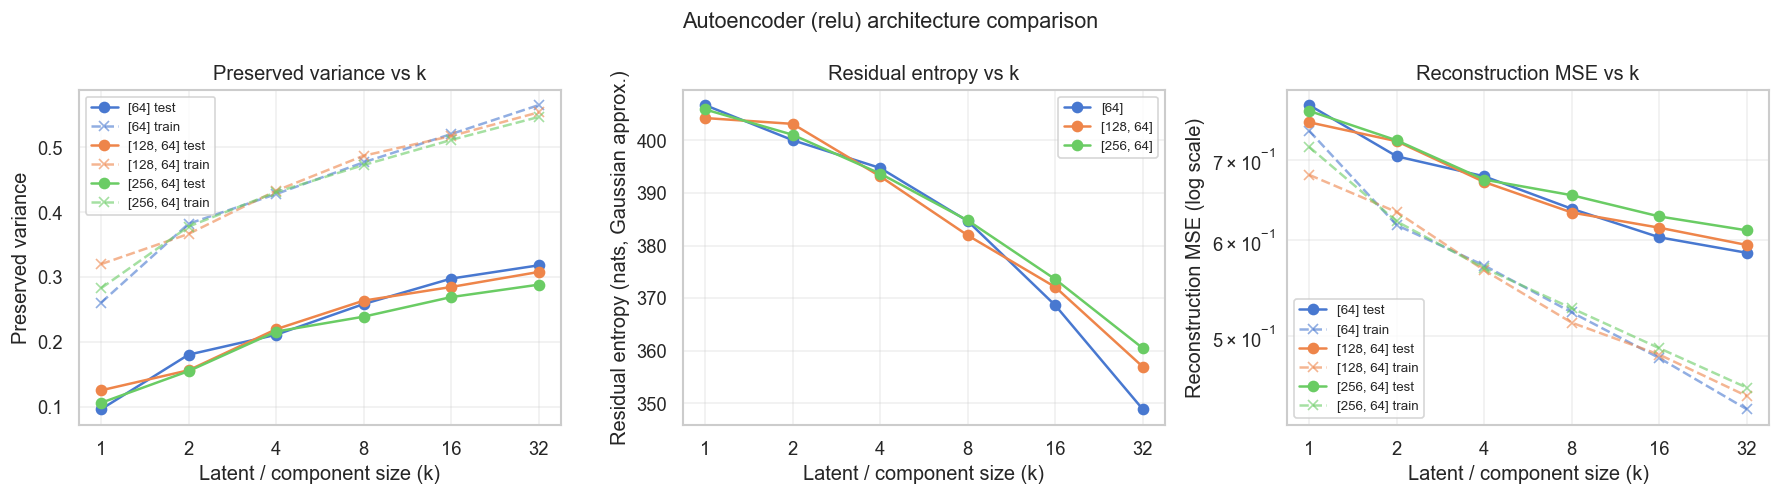

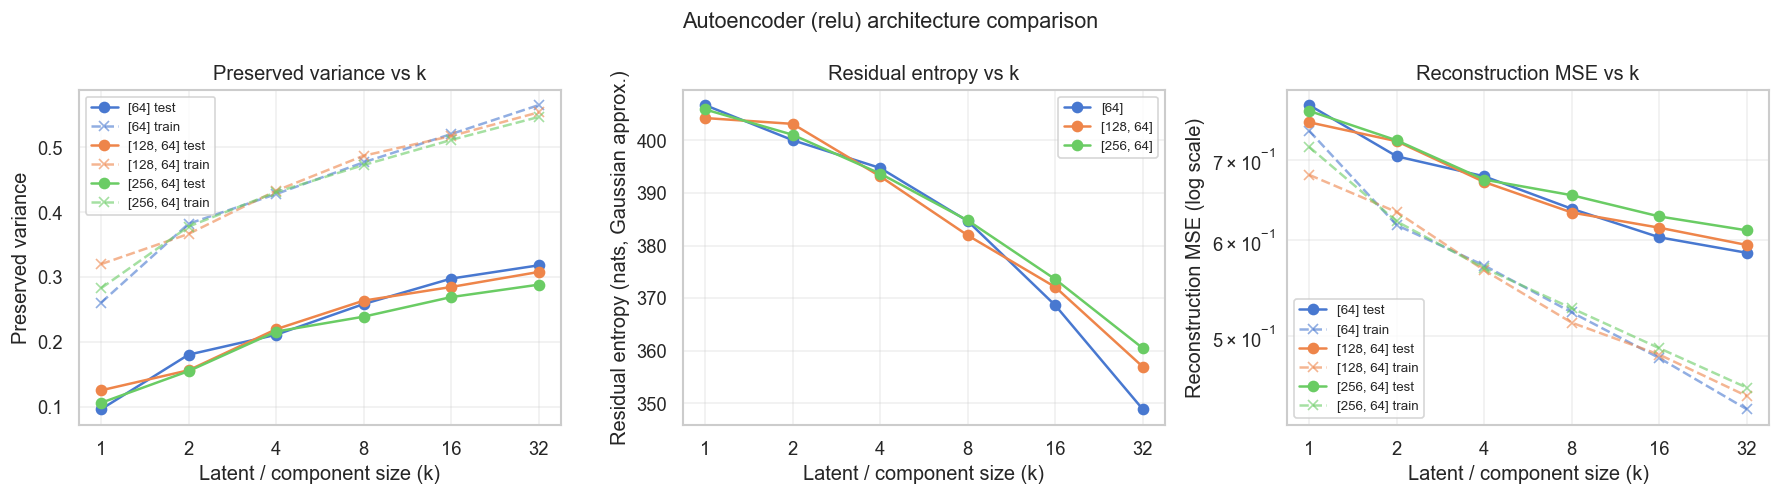

In [6]:
architectures = {
    '[64]':         {'encoder_hidden': [64],       'decoder_hidden': [64]},
    '[128, 64]':    {'encoder_hidden': [128, 64],  'decoder_hidden': [64, 128]},
    '[256, 64]':    {'encoder_hidden': [256, 64],  'decoder_hidden': [64, 256]},
}
activation = 'relu'

architecture_results = {}
for label, arch in architectures.items():
    print(f'\n=== architecture {label} ===')
    df = ae_mod.run_ae_experiment(
        data,
        component_grid=ae_mod.COMPONENT_GRID,
        activation=activation,
        **arch,
    )
    safe = label.replace(' ', '').replace(',', '_').replace('[', '').replace(']', '')
    df.to_csv(RESULTS_DIR + f'autoencoder_arch_{safe}.csv', float_format='%.6f')
    architecture_results[label] = df

plotting_mod.plot_experiments_comparison(
    architecture_results,
    title=f'Autoencoder ({activation}) architecture comparison',
    save_path=PLOTS_DIR + 'plot_architecture_comparison.png',
)

## 6. Variational Autoencoder (VAE) on its own
Same architecture spec as the AE, but the latent is stochastic: the
encoder emits a Gaussian posterior (`mu`, `logvar`) and the loss adds a
KL term pulling it toward a standard normal prior. Reconstruction metrics
use the deterministic posterior mean `mu`, so they stay directly
comparable to PCA and the AE. `beta` is the KL weight (the VAE-specific knob).

[VAE/relu/beta=0.1] k=  1  training [470 -> 64] -> mu/logvar(1) -> z(1) -> [64 -> 470] ...
[VAE/relu/beta=0.1] k=  1  train R^2=0.3289  test R^2=0.1440  train MSE=0.6711  test MSE=0.7356  KL=5.601
[VAE/relu/beta=0.1] k=  2  training [470 -> 64] -> mu/logvar(2) -> z(2) -> [64 -> 470] ...
[VAE/relu/beta=0.1] k=  2  train R^2=0.3825  test R^2=0.1837  train MSE=0.6175  test MSE=0.7015  KL=11.631
[VAE/relu/beta=0.1] k=  4  training [470 -> 64] -> mu/logvar(4) -> z(4) -> [64 -> 470] ...
[VAE/relu/beta=0.1] k=  4  train R^2=0.4318  test R^2=0.2182  train MSE=0.5682  test MSE=0.6719  KL=20.724
[VAE/relu/beta=0.1] k=  8  training [470 -> 64] -> mu/logvar(8) -> z(8) -> [64 -> 470] ...
[VAE/relu/beta=0.1] k=  8  train R^2=0.4821  test R^2=0.2621  train MSE=0.5179  test MSE=0.6341  KL=32.331
[VAE/relu/beta=0.1] k= 16  training [470 -> 64] -> mu/logvar(16) -> z(16) -> [64 -> 470] ...
[VAE/relu/beta=0.1] k= 16  train R^2=0.5275  test R^2=0.2923  train MSE=0.4725  test MSE=0.6082  KL=50.082
[VAE/relu

,train_preserved_variance,test_preserved_variance,residual_entropy,train_mse,test_mse,train_kl
k,,,,,,
1,0.328905,0.144033,401.777965,0.671095,0.735628,5.600960
2,0.382465,0.183710,401.124650,0.617535,0.701529,11.630993
4,0.431845,0.218160,393.548780,0.568155,0.671923,20.724087
8,0.482062,0.262138,383.692312,0.517938,0.634127,32.331020
16,0.527486,0.292288,369.161385,0.472514,0.608216,50.082153
32,0.562080,0.316967,355.406323,0.437920,0.587007,77.055817


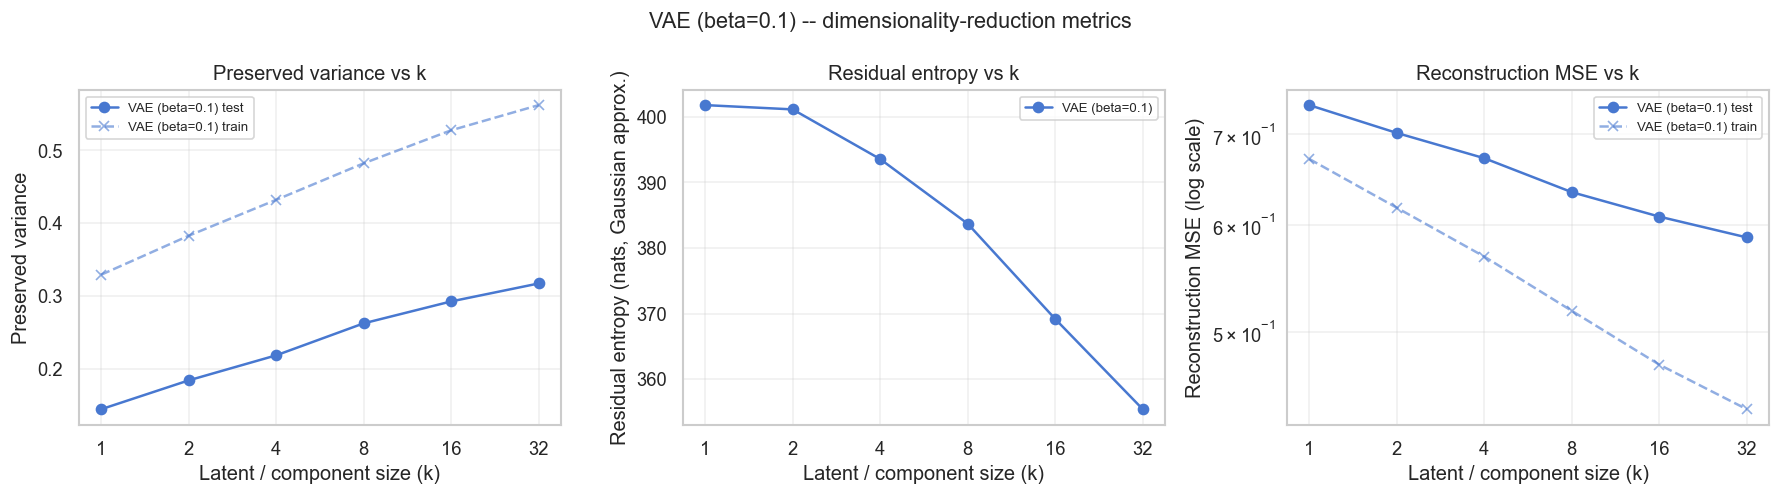

In [7]:
vae_encoder_hidden = [64]
vae_decoder_hidden = [64]
vae_activation     = 'relu'
vae_beta           = 0.1

vae_results = vae_mod.run_vae_experiment(
    data,
    component_grid=vae_mod.COMPONENT_GRID,
    encoder_hidden=vae_encoder_hidden,
    decoder_hidden=vae_decoder_hidden,
    activation=vae_activation,
    beta=vae_beta,
)
vae_results.to_csv(RESULTS_DIR + f'vae_experiments_beta{vae_beta}.csv', float_format='%.6f')

plotting_mod.plot_experiments_comparison(
    {f'VAE (beta={vae_beta})': vae_results},
    title=f'VAE (beta={vae_beta}) -- dimensionality-reduction metrics',
    save_path=PLOTS_DIR + 'plot_vae_experiments.png',
)
vae_results.round(6)


## 6b. Student-t VAE (VAE-t) on its own
Same architecture and MSE reconstruction as the Gaussian VAE, but the latent
**prior and posterior are heavy-tailed** (diagonal Student-t). `nu` is the
degrees-of-freedom / tail knob (smaller = heavier tails; large `nu` approaches
the Gaussian VAE); set `vae_t_learn_nu=True` to learn a single global `nu`
instead of fixing it. The KL term is a Monte-Carlo estimate (Student-t has no
closed-form KL). Reconstruction metrics use the deterministic posterior
**location**, so they stay directly comparable to PCA / AE / VAE. The extra
`train_kl` / `nu_value` columns are VAE-t diagnostics the comparison plot ignores.

In [ ]:
vae_t_encoder_hidden = [64]
vae_t_decoder_hidden = [64]
vae_t_activation     = 'relu'
vae_t_beta           = 1.0
vae_t_nu             = 3.0     # Student-t degrees of freedom (smaller = heavier tails)
vae_t_learn_nu       = False   # set True to learn a single global nu instead

vae_t_results = vaet_mod.run_vae_tstudent_experiment(
    data,
    component_grid=vaet_mod.COMPONENT_GRID,
    encoder_hidden=vae_t_encoder_hidden,
    decoder_hidden=vae_t_decoder_hidden,
    activation=vae_t_activation,
    beta=vae_t_beta,
    nu=vae_t_nu,
    learn_nu=vae_t_learn_nu,
)
vae_t_results.to_csv(RESULTS_DIR + f'vae_tstudent_experiments_nu{vae_t_nu}.csv', float_format='%.6f')

plotting_mod.plot_experiments_comparison(
    {f'VAE-t (nu={vae_t_nu})': vae_t_results},
    title=f'Student-t VAE (nu={vae_t_nu}) -- dimensionality-reduction metrics',
    save_path=PLOTS_DIR + 'plot_vae_tstudent_experiments.png',
)
vae_t_results.round(6)

## 7. PCA vs Autoencoder vs VAE vs Student-t VAE
All four methods on one figure. Colour = method, linestyle = split
(test solid + circle, train dashed + x). Re-uses the results computed
above -- no retraining.

In [ ]:
plotting_mod.plot_experiments_comparison(
    {
        'PCA':   pca_results,
        'AE':    ae_results,
        'VAE':   vae_results,
        'VAE-t': vae_t_results,
    },
    title='PCA vs Autoencoder vs VAE vs Student-t VAE -- dimensionality-reduction metrics',
    save_path=PLOTS_DIR + 'plot_pca_ae_vae_vaet.png',
)

## 8. VAE beta sweep
`beta` trades reconstruction against latent regularisation: `beta` < 1
leans toward a plain autoencoder (better reconstruction, less structured
latent), `beta` = 1 is the standard VAE, `beta` > 1 is a beta-VAE (more
regularised, usually worse reconstruction). Colour = beta. Edit
`vae_mod.BETA_GRID` or the list below to change the sweep.

--- beta = 0.1 ---
[VAE/relu/beta=0.1] k=  1  training [470 -> 64] -> mu/logvar(1) -> z(1) -> [64 -> 470] ...
[VAE/relu/beta=0.1] k=  1  train R^2=0.3289  test R^2=0.1440  train MSE=0.6711  test MSE=0.7356  KL=5.601
[VAE/relu/beta=0.1] k=  2  training [470 -> 64] -> mu/logvar(2) -> z(2) -> [64 -> 470] ...
[VAE/relu/beta=0.1] k=  2  train R^2=0.3825  test R^2=0.1837  train MSE=0.6175  test MSE=0.7015  KL=11.631
[VAE/relu/beta=0.1] k=  4  training [470 -> 64] -> mu/logvar(4) -> z(4) -> [64 -> 470] ...
[VAE/relu/beta=0.1] k=  4  train R^2=0.4318  test R^2=0.2182  train MSE=0.5682  test MSE=0.6719  KL=20.724
[VAE/relu/beta=0.1] k=  8  training [470 -> 64] -> mu/logvar(8) -> z(8) -> [64 -> 470] ...
[VAE/relu/beta=0.1] k=  8  train R^2=0.4821  test R^2=0.2621  train MSE=0.5179  test MSE=0.6341  KL=32.331
[VAE/relu/beta=0.1] k= 16  training [470 -> 64] -> mu/logvar(16) -> z(16) -> [64 -> 470] ...
[VAE/relu/beta=0.1] k= 16  train R^2=0.5275  test R^2=0.2923  train MSE=0.4725  test MSE=0.6082  

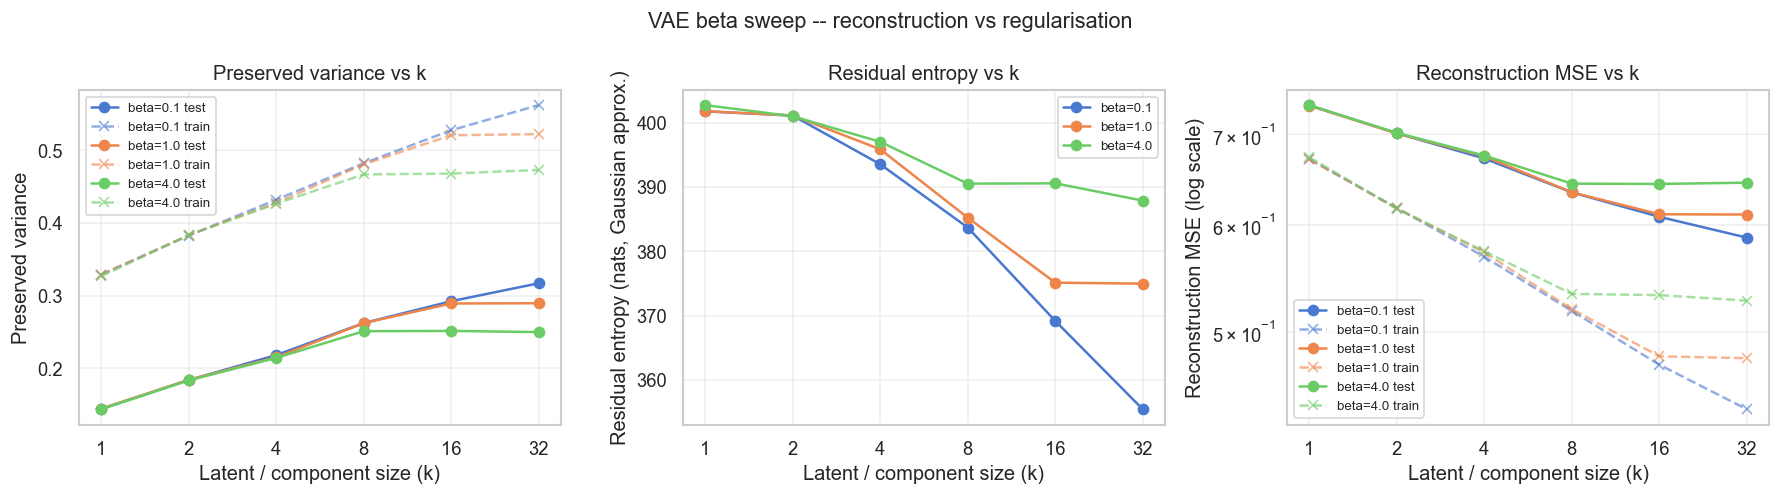

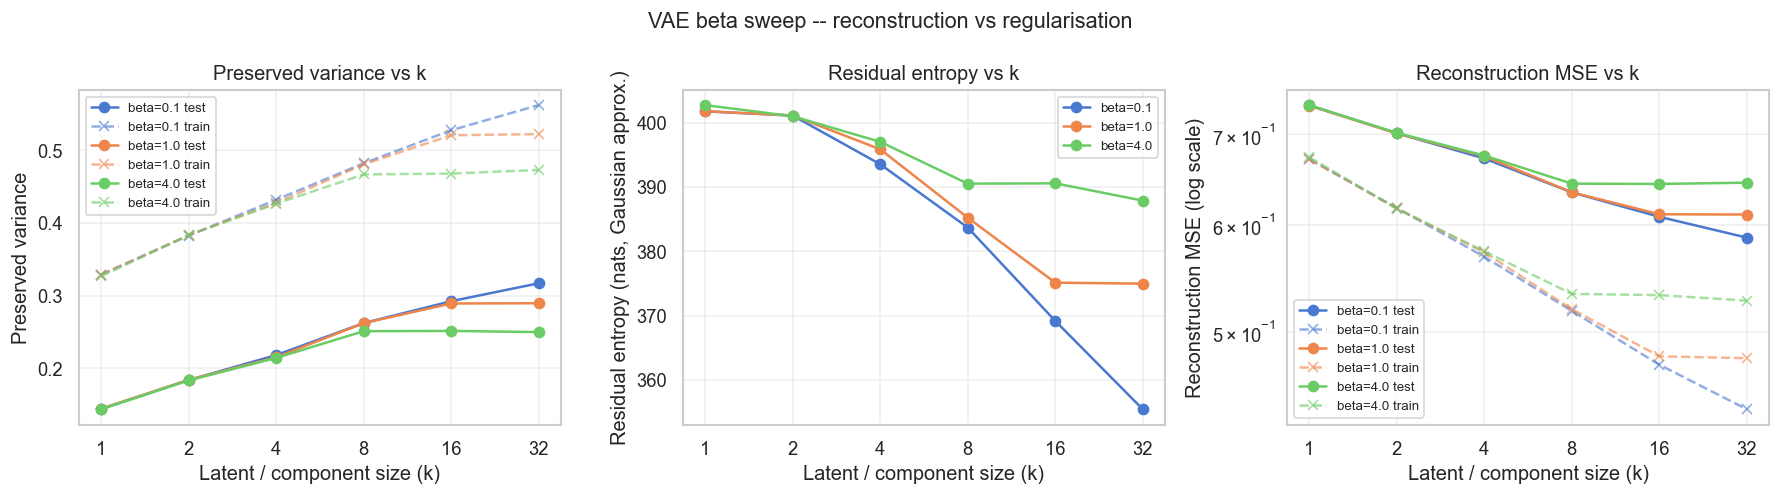

In [9]:
vae_encoder_hidden = [64]
vae_decoder_hidden = [64]
vae_activation     = 'relu'

beta_results = {}
for b in vae_mod.BETA_GRID:
    print(f'--- beta = {b} ---')
    df = vae_mod.run_vae_experiment(
        data,
        component_grid=vae_mod.COMPONENT_GRID,
        encoder_hidden=vae_encoder_hidden,
        decoder_hidden=vae_decoder_hidden,
        activation=vae_activation,
        beta=b,
    )
    df.to_csv(RESULTS_DIR + f'vae_experiments_beta{b}.csv', float_format='%.6f')
    beta_results[b] = df

plotting_mod.plot_experiments_comparison(
    {f'beta={b}': df for b, df in beta_results.items()},
    title='VAE beta sweep -- reconstruction vs regularisation',
    save_path=PLOTS_DIR + 'plot_vae_beta_sweep.png',
)


## 8b. VAE-t degrees-of-freedom (nu) sweep
`nu` sets the latent tail heaviness: small `nu` = heavy tails (far from
Gaussian), large `nu` -> approaches the Gaussian VAE. We sweep the fixed values
in `vaet_mod.NU_GRID` and also train one model that **learns** `nu` (a single
global scalar). Colour = `nu`. The learned run's fitted `nu` is in each row's
`nu_value` column.

In [ ]:
vae_t_encoder_hidden = [64]
vae_t_decoder_hidden = [64]
vae_t_activation     = 'relu'
vae_t_beta           = 1.0

nu_results = {}
for nu in vaet_mod.NU_GRID:
    print(f'--- nu = {nu} ---')
    df = vaet_mod.run_vae_tstudent_experiment(
        data,
        component_grid=vaet_mod.COMPONENT_GRID,
        encoder_hidden=vae_t_encoder_hidden,
        decoder_hidden=vae_t_decoder_hidden,
        activation=vae_t_activation,
        beta=vae_t_beta,
        nu=nu,
    )
    df.to_csv(RESULTS_DIR + f'vae_tstudent_experiments_nu{nu}.csv', float_format='%.6f')
    nu_results[f'nu={nu}'] = df

# Also LEARN nu (a single global scalar) rather than fixing it.
print('--- nu = learned ---')
df_learn = vaet_mod.run_vae_tstudent_experiment(
    data,
    component_grid=vaet_mod.COMPONENT_GRID,
    encoder_hidden=vae_t_encoder_hidden,
    decoder_hidden=vae_t_decoder_hidden,
    activation=vae_t_activation,
    beta=vae_t_beta,
    nu=3.0,
    learn_nu=True,
)
df_learn.to_csv(RESULTS_DIR + 'vae_tstudent_experiments_nulearned.csv', float_format='%.6f')
nu_results['nu=learned'] = df_learn

plotting_mod.plot_experiments_comparison(
    nu_results,
    title='Student-t VAE nu sweep -- latent tail heaviness',
    save_path=PLOTS_DIR + 'plot_vae_tstudent_nu_sweep.png',
)

## 9. Summary table
Test-split numbers for every experiment computed in this notebook.

In [ ]:
import pandas as pd

summary = {'PCA': pca_results, 'AE': ae_results, 'VAE': vae_results, 'VAE-t': vae_t_results}
summary.update({f'AE {act}': df for act, df in activation_results.items()})
summary.update({f'AE arch {label}': df for label, df in architecture_results.items()})
summary.update({f'VAE beta={b}': df for b, df in beta_results.items()})
summary.update({f'VAE-t {label}': df for label, df in nu_results.items()})

summary_table = pd.concat(
    {label: df[['test_preserved_variance', 'residual_entropy', 'test_mse']]
     for label, df in summary.items()},
    axis=1,
)
summary_table.round(6)

## 10. Downstream usefulness -- next-step prediction
The reconstruction sections measure how well each method *rebuilds* X.
This one measures how *useful* the captured features are: for each
method we encode `X_t`, then train a small predictor to forecast the
**next day's return vector `X_{t+1}`** from the current latent `z_t`.

The target is the next *input* (identical for every method), so the
input-space error is directly comparable and is not confounded by any
decoder. We run **both a linear probe and an MLP**, and draw two
reference lines: an uncompressed **full-X** predictor and a **naive**
predict-the-mean baseline. Latent features are standardised (train
stats) before the predictor so PCA scores and AE/VAE codes compete on
equal footing.

> Daily returns are near-unpredictable in the mean (efficient market),
> so expect R^2 close to 0 for everyone -- read the **relative** ordering
> of the methods and how it moves with `k`, not the absolute level.
>
> This retrains each AE/VAE encoder once per `k`, so it is the most
> expensive section; shrink `pred_component_grid` for a quick look.

In [ ]:
# Encoder settings per method (match the earlier AE / VAE / VAE-t cells).
ae_kwargs   = {'encoder_hidden': [64], 'decoder_hidden': [64], 'activation': 'relu'}
vae_kwargs  = {'encoder_hidden': [64], 'decoder_hidden': [64], 'activation': 'relu', 'beta': 1.0}
vaet_kwargs = {'encoder_hidden': [64], 'decoder_hidden': [64], 'activation': 'relu', 'beta': 1.0, 'nu': 3.0}
method_kwargs = {'PCA': {}, 'AE': ae_kwargs, 'VAE': vae_kwargs, 'VAE-t': vaet_kwargs}

pred_component_grid = pred_mod.COMPONENT_GRID
hidden_list = [[], [64]]        # linear probe + 1-hidden MLP

# {method: {predictor_tag: results_df}} -- encodes once per k, scores both probes.
pred_by_method = {}
for m in ['PCA', 'AE', 'VAE', 'VAE-t']:
    print(f'\n########## method = {m} ##########')
    pred_by_method[m] = pred_mod.run_prediction_experiment_multi(
        data, m,
        component_grid=pred_component_grid,
        hidden_list=hidden_list,
        encoder_kwargs=method_kwargs[m],
    )

# Baselines (constant in k): one full-X predictor per probe, plus the naive line.
baselines = {}
for h, tag in [([], 'linear'), ([64], 'mlp[64]')]:
    baselines[tag] = {
        'full-X': pred_mod.full_x_baseline(data, hidden=h),
        'naive':  pred_mod.naive_baseline(data),
    }
print('\ndone.')

### 10a. Linear probe
How much next-step signal is **linearly** recoverable from each latent.

In [ ]:
linear_results = {m: pred_by_method[m]['linear'] for m in ['PCA', 'AE', 'VAE', 'VAE-t']}
plotting_mod.plot_prediction_comparison(
    linear_results,
    baselines=baselines['linear'],
    title='Downstream next-step prediction -- linear probe',
    save_path=PLOTS_DIR + 'plot_prediction_linear.png',
)

### 10b. MLP probe
Same task with a one-hidden-layer MLP -- how much a bit of nonlinearity adds.

In [ ]:
mlp_results = {m: pred_by_method[m]['mlp[64]'] for m in ['PCA', 'AE', 'VAE', 'VAE-t']}
plotting_mod.plot_prediction_comparison(
    mlp_results,
    baselines=baselines['mlp[64]'],
    title='Downstream next-step prediction -- MLP probe',
    save_path=PLOTS_DIR + 'plot_prediction_mlp.png',
)

### 10c. Prediction summary
Test-split next-step R^2 and MSE for every method x probe.

In [ ]:
import pandas as pd

pred_summary = {}
for tag in ['linear', 'mlp[64]']:
    for m in ['PCA', 'AE', 'VAE', 'VAE-t']:
        pred_summary[f'{m} ({tag})'] = pred_by_method[m][tag]

pred_table = pd.concat(
    {label: df[['test_pred_r2', 'test_pred_mse']] for label, df in pred_summary.items()},
    axis=1,
)
pred_table.round(6)